### Importing and Installing Libraries

In [ ]:
!pip3 install -U ucimlrepo
!pip install scikit-learn
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import plotly.graph_objs as go
import plotly.io as pio



### Importing the Dataset - radius1 --> mean, radius2 --> standard error, radius3 --> worse value/case


In [ ]:
from ucimlrepo import fetch_ucirepo
# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

# metadata
print(breast_cancer_wisconsin_diagnostic.metadata)

# variable information
print(breast_cancer_wisconsin_diagnostic.variables)

{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

In [ ]:
#Calculates the number of columns features + target (diagnosis)
num_features = X.shape[1]
num_targets = y.shape[1] if isinstance(y, pd.DataFrame) else 1
total_columns = num_features + num_targets

print(f"Number of features: {num_features}")
print(f"Number of target variables: {num_targets}")
print(f"Total number of columns (features + target): {total_columns}")

Number of features: 30
Number of target variables: 1
Total number of columns (features + target): 31


# **Exploratory data analysis**: Data cleaning, descriptive statistics, visualizations, correlation


### Understanding the values for the features to differentiate between Cancerous and Non Cancerous cells

In [ ]:
#Displaying 1st 5 rows of features and target
print(breast_cancer_wisconsin_diagnostic.data.features.head())
print(breast_cancer_wisconsin_diagnostic.data.targets.head())

   radius1  texture1  perimeter1   area1  smoothness1  compactness1  \
0    17.99     10.38      122.80  1001.0      0.11840       0.27760   
1    20.57     17.77      132.90  1326.0      0.08474       0.07864   
2    19.69     21.25      130.00  1203.0      0.10960       0.15990   
3    11.42     20.38       77.58   386.1      0.14250       0.28390   
4    20.29     14.34      135.10  1297.0      0.10030       0.13280   

   concavity1  concave_points1  symmetry1  fractal_dimension1  ...  radius3  \
0      0.3001          0.14710     0.2419             0.07871  ...    25.38   
1      0.0869          0.07017     0.1812             0.05667  ...    24.99   
2      0.1974          0.12790     0.2069             0.05999  ...    23.57   
3      0.2414          0.10520     0.2597             0.09744  ...    14.91   
4      0.1980          0.10430     0.1809             0.05883  ...    22.54   

   texture3  perimeter3   area3  smoothness3  compactness3  concavity3  \
0     17.33      184.60 

### Data Cleaning: Checking for Missing Data


In [ ]:
# Check for missing values, there is no missing value here which makes it easy to work on.
print("Missing values in features:\n", X.isnull().sum())
print("\nMissing values in target:\n", y.isnull().sum())
print("\nSummary Statistics:\n", X.describe())


Missing values in features:
 radius1               0
texture1              0
perimeter1            0
area1                 0
smoothness1           0
compactness1          0
concavity1            0
concave_points1       0
symmetry1             0
fractal_dimension1    0
radius2               0
texture2              0
perimeter2            0
area2                 0
smoothness2           0
compactness2          0
concavity2            0
concave_points2       0
symmetry2             0
fractal_dimension2    0
radius3               0
texture3              0
perimeter3            0
area3                 0
smoothness3           0
compactness3          0
concavity3            0
concave_points3       0
symmetry3             0
fractal_dimension3    0
dtype: int64

Missing values in target:
 Diagnosis    0
dtype: int64

Summary Statistics:
           radius1    texture1  perimeter1        area1  smoothness1  \
count  569.000000  569.000000  569.000000   569.000000   569.000000   
mean    14.127292 

### Looking for Outliers

In [ ]:
# Select the important features excluding area1, radius1, perimeter1, texture1
selected_features = ['smoothness1', 'compactness1', 'concavity1', 'concave_points1', 'symmetry1', 'fractal_dimension1']

# Convert the selected features to a list of lists for plotting
values = [X[feature].tolist() for feature in selected_features]

# Define vibrant colors for each feature
vibrant_colors = ['#FF5733', '#33FF57', '#3357FF', '#FF33A1', '#FF8C33', '#00CED1']

# Create the Plotly figure
fig = go.Figure()

# Loop through the features, adding a box trace for each one
for feature_name, feature_values, color in zip(selected_features, values, vibrant_colors):
    fig.add_trace(go.Box(
        y=feature_values,
        name=feature_name,
        boxpoints='outliers',  # Show outliers
        jitter=0.1,            # Increase jitter to spread out points more evenly
        whiskerwidth=0.4,
        fillcolor=color,
        marker=dict(size=8, line=dict(width=1.5)),
        line=dict(width=2)
    ))

# Set figure layout for better aesthetics
fig.update_layout(
    title='Outlier Detection for Selected Features Using Boxplots',
    title_font_size=20,
    yaxis=dict(
        title='Value',
        zeroline=False,
    ),
    xaxis=dict(
        title='Feature',
    ),
    font=dict(size=14),
    boxmode='group',  # Group the boxplots together for easy comparison
    paper_bgcolor='white',  # Set background to white for a clean look
    plot_bgcolor='#f9f9f9'  # Set plot area background to a light grey for contrast
)

# Show the figure
fig.show()


### Visualization with the Distribution of Benign and Malignant Cases Using a Pie Chart

<ipython-input-41-40f254283129>:6: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



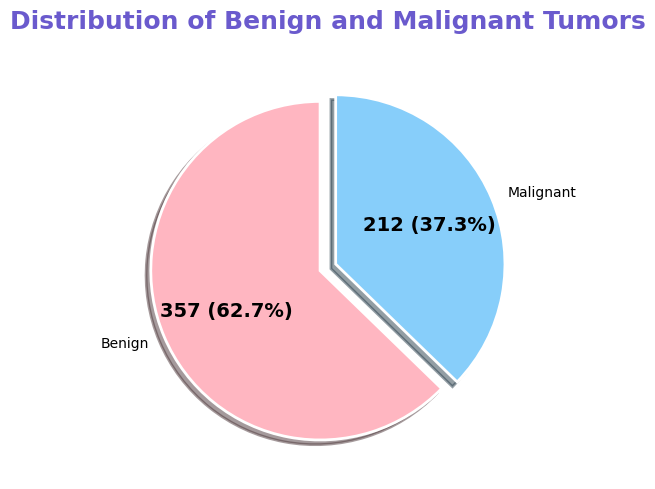

In [ ]:
# Calculate the counts for benign (0) and malignant (1)
target_counts = y['Diagnosis'].value_counts()

# Define labels and values for the pie chart
labels = ['Benign', 'Malignant']
values = [target_counts[0], target_counts[1]]
colors = ['#FFB6C1', '#87CEFA']  # Light pink for benign and sky blue for malignant

# Plotting the pie chart
plt.figure(figsize=(9, 5))
wedges, texts, autotexts = plt.pie(
    values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}, explode=[0.05, 0.05], shadow=True
)

# Add the count along with the percentage for each slice
for i, autotext in enumerate(autotexts):
    autotext.set_text(f"{values[i]} ({autotext.get_text()})")
    autotext.set_fontsize(14)
    autotext.set_fontweight('bold')
    autotext.set_color('black')

# Add a title with a cute font style
plt.title('Distribution of Benign and Malignant Tumors', fontsize=18, fontweight='bold', color='#6A5ACD', pad=20)

# Display the pie chart
plt.tight_layout()
plt.show()



###Checking what are the values in the Diagnosis column to perform label encoding to change categorical values to numerical

In [ ]:
# Check the column name(s) in targets
print(breast_cancer_wisconsin_diagnostic.data.targets.columns)

# Assuming the column is named 'Diagnosis', get unique values
print("Unique values in 'Diagnosis':", breast_cancer_wisconsin_diagnostic.data.targets['Diagnosis'].unique())

Index(['Diagnosis'], dtype='object')
Unique values in 'Diagnosis': ['M' 'B']


### Changing M --> 1 (cancerous) and B --> 0 (non-cancerous)

In [ ]:
# Use .loc to modify the Diagnosis column
breast_cancer_wisconsin_diagnostic.data.targets.loc[:, 'Diagnosis'] = breast_cancer_wisconsin_diagnostic.data.targets['Diagnosis'].map({'M': 1, 'B': 0})

# Verify the conversion by checking unique values
print("Unique values in 'Diagnosis' after encoding:", breast_cancer_wisconsin_diagnostic.data.targets['Diagnosis'].unique())

Unique values in 'Diagnosis' after encoding: [1 0]


### Checking if label encoding has been applied succesfully to proceed with further steps - *SUCCESSFUL*

In [ ]:
# Display the first 15 rows of the target variable (y) - checking if label encoding was successful.

print(y.head(20))

   Diagnosis
0          1
1          1
2          1
3          1
4          1
5          1
6          1
7          1
8          1
9          1
10         1
11         1
12         1
13         1
14         1
15         1
16         1
17         1
18         1
19         0


In [ ]:
# Count the number of benign (0) and malignant (1) cases in the 'Diagnosis' column
target_counts = breast_cancer_wisconsin_diagnostic.data.targets['Diagnosis'].value_counts()

# Display the count for each class
print(f"Class 0 (Benign): {target_counts[0]} cases")
print(f"Class 1 (Malignant): {target_counts[1]} cases")


Class 0 (Benign): 357 cases
Class 1 (Malignant): 212 cases


### Visualization with Feature Correlations (Values Near 1 Indicate Stronger Relationships)

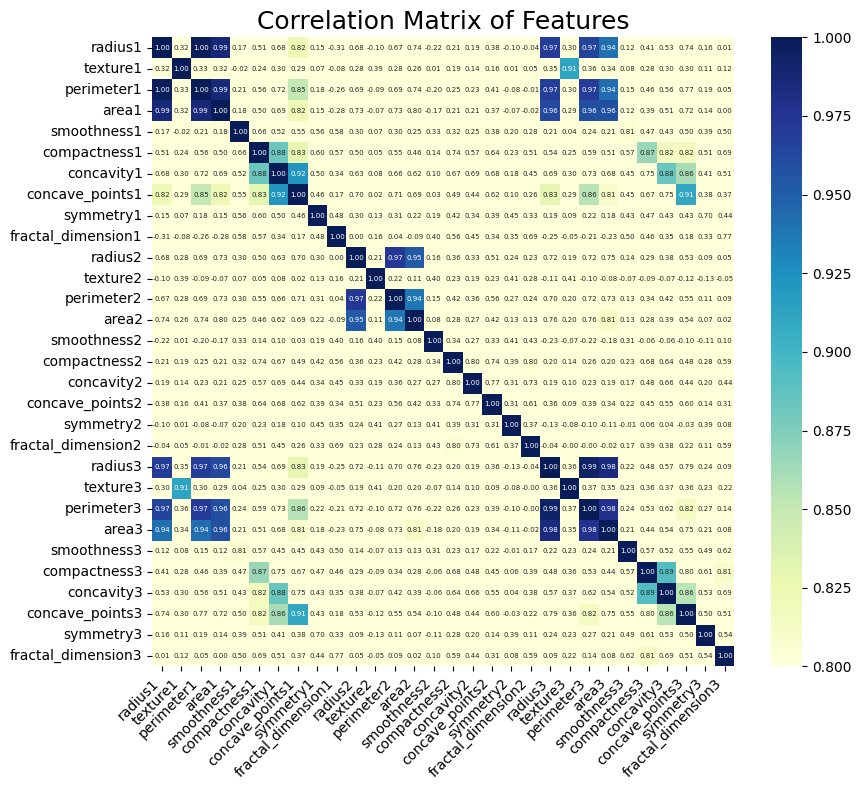

In [ ]:
plt.figure(figsize=(9, 8))
# Set annot=True to display correlation values, adjust the font size to fit in the boxes neatly
sns.heatmap(X.corr(), annot=True, vmin=0.80, vmax=1, cmap="YlGnBu", cbar=True, fmt=".2f", annot_kws={"size": 5})
plt.title("Correlation Matrix of Features", fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Visualization with Pair Plots

<ipython-input-47-c6ec3b12b55e>:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



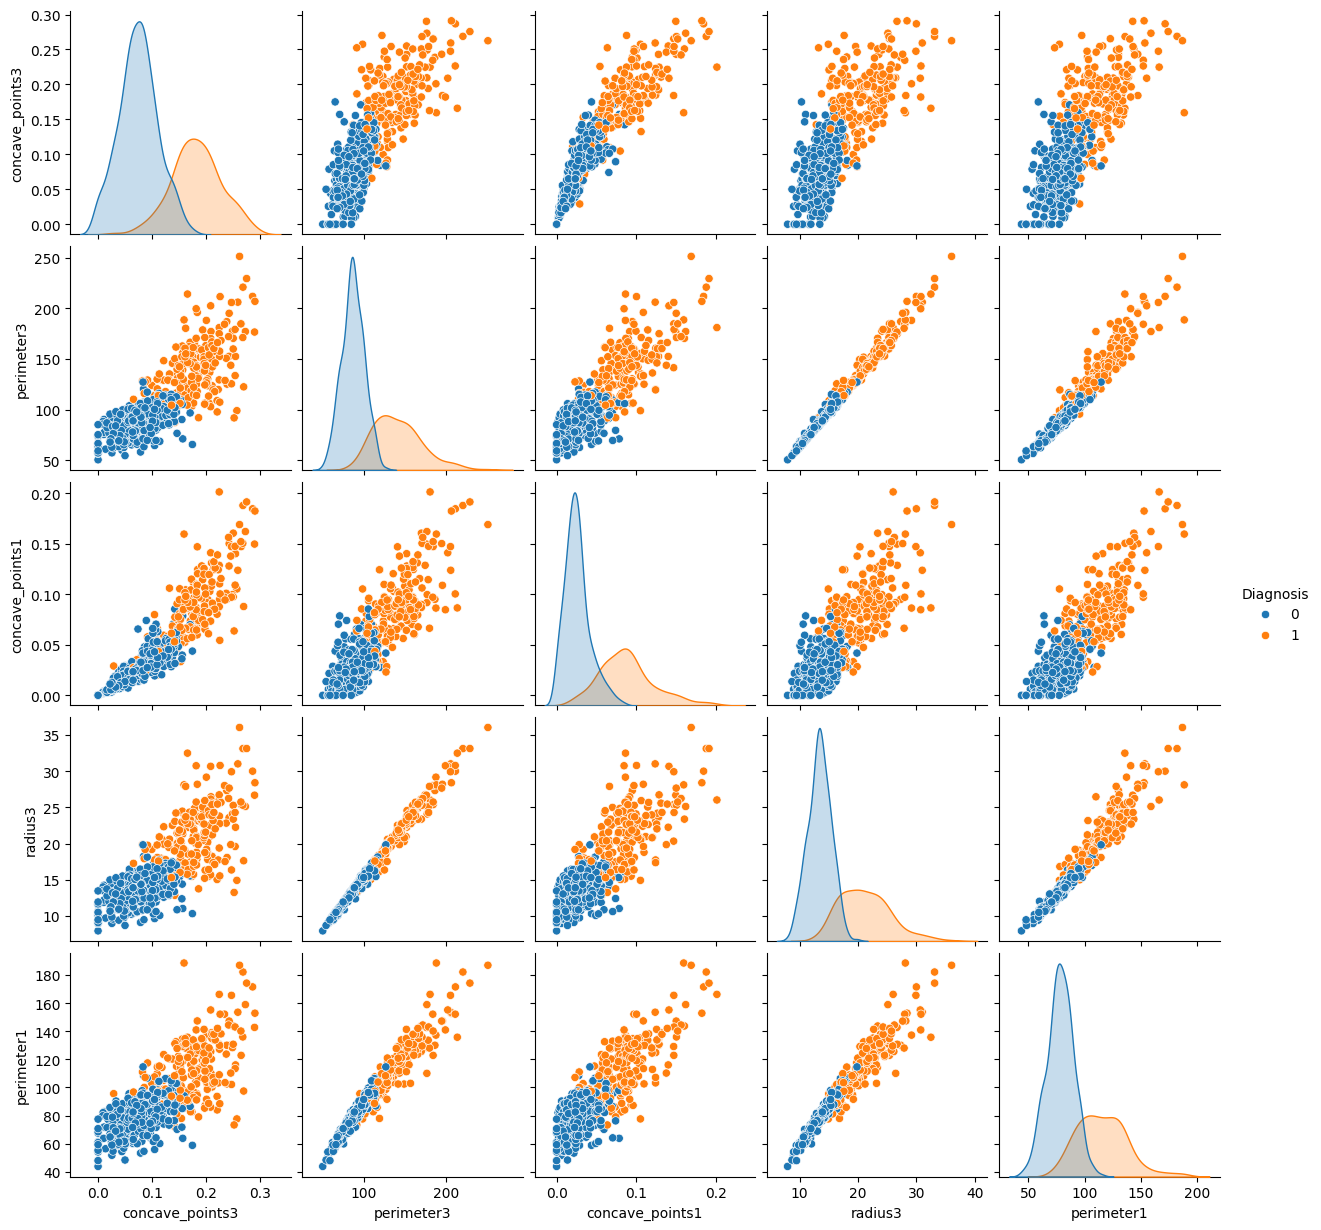

In [ ]:

y['Diagnosis'] = pd.to_numeric(y['Diagnosis'])

data = pd.concat([X, y], axis=1)

# Calculate the correlations
correlations = data.corr()['Diagnosis'].drop('Diagnosis')  # Exclude self-correlation

# Extract top 5 most correlated features
top_5_features = correlations.abs().nlargest(5).index

# Create a pair plot for the top 5 features and diagnosis
sns.pairplot(data[top_5_features.tolist() + ['Diagnosis']], hue='Diagnosis')
plt.show()

### Visualization with Histoplot

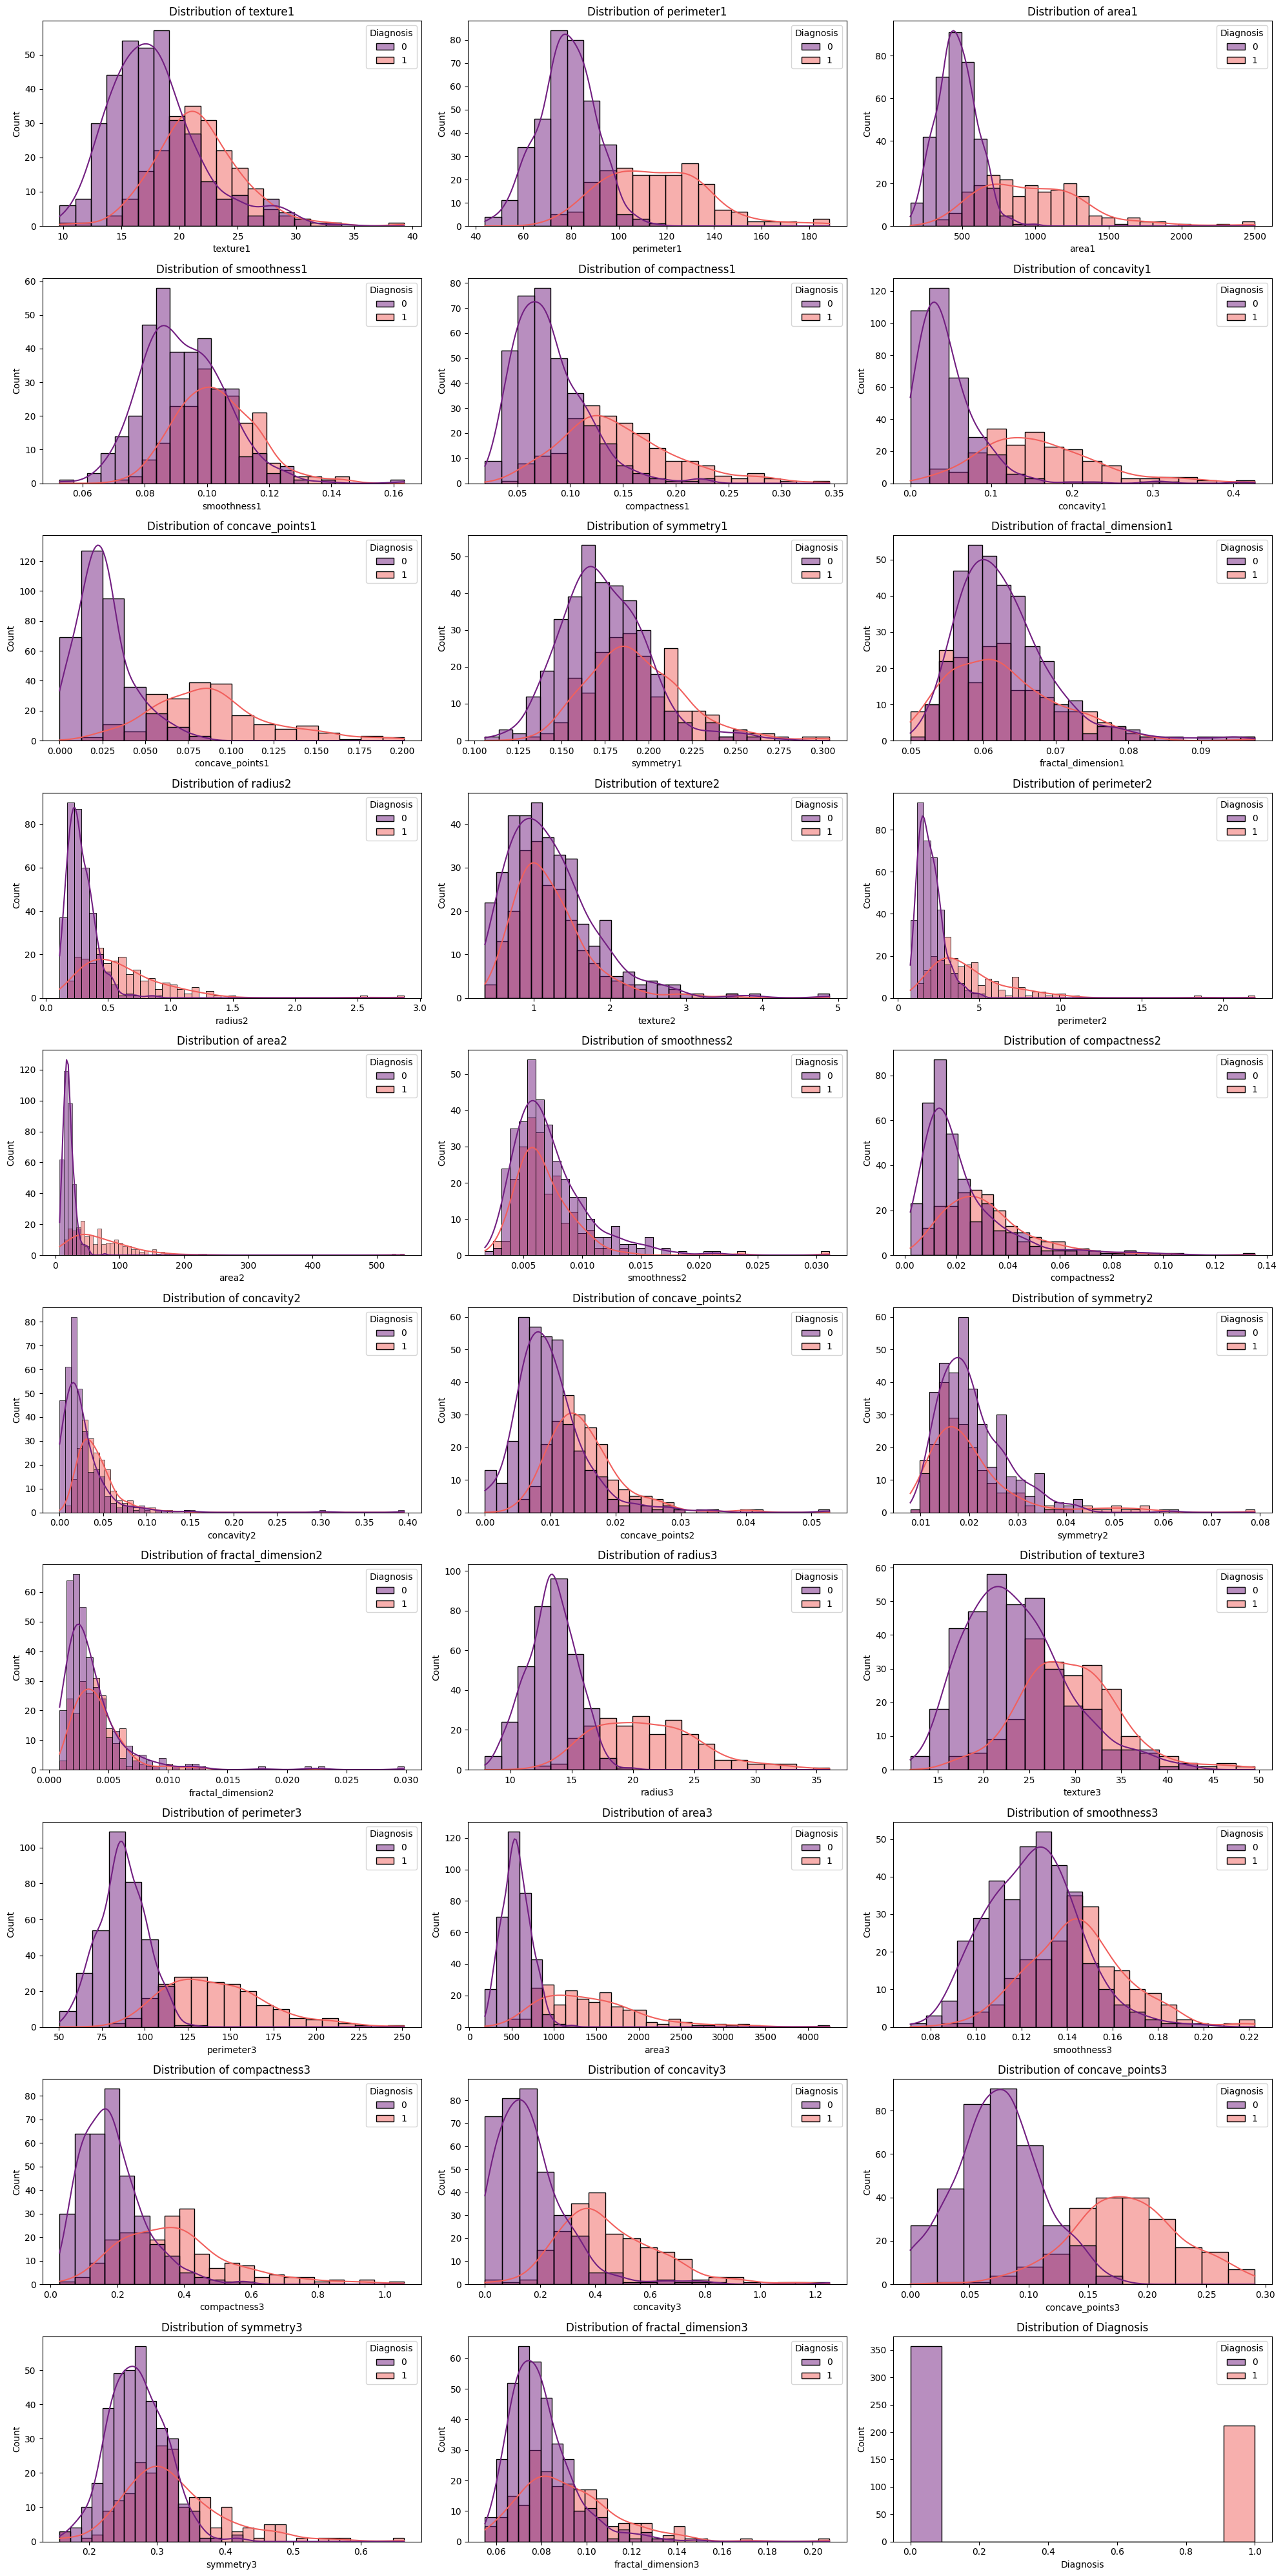

In [ ]:

plt.figure(figsize=(20, 40))
for i, column in enumerate(data.columns[1:]):
    plt.subplot(10, 3, i+1)
    sns.histplot(data=data, x=column, hue='Diagnosis', kde=True, palette='magma')
    plt.title(f'Distribution of {column}')
plt.tight_layout()
plt.show()

# **Pre-Processing Steps**

###Splitting dataset into 80% training and 20% testing sets


In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((455, 30), (114, 30), (455, 1), (114, 1))

### Using StandardScaler

In [ ]:
from sklearn.preprocessing import StandardScaler

# Standardize the features using StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train = scaler.fit_transform(X_train)  # Fit and transform the training set
X_test = scaler.transform(X_test)

# **Predictive Analytics**

### Feedforward Neural Network (Multi-Layer Perceptron)

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best parameters from Grid Search: {'activation': 'relu', 'early_stopping': True, 'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.01, 'max_iter': 1000, 'solver': 'adam'}
MLP Accuracy: 0.9736842105263158
              precision    recall  f1-score   support

           0       0.99      0.97      0.98        71
           1       0.95      0.98      0.97        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

MLP Training Accuracy: 0.9956043956043956
MLP Testing Accuracy: 0.9736842105263158


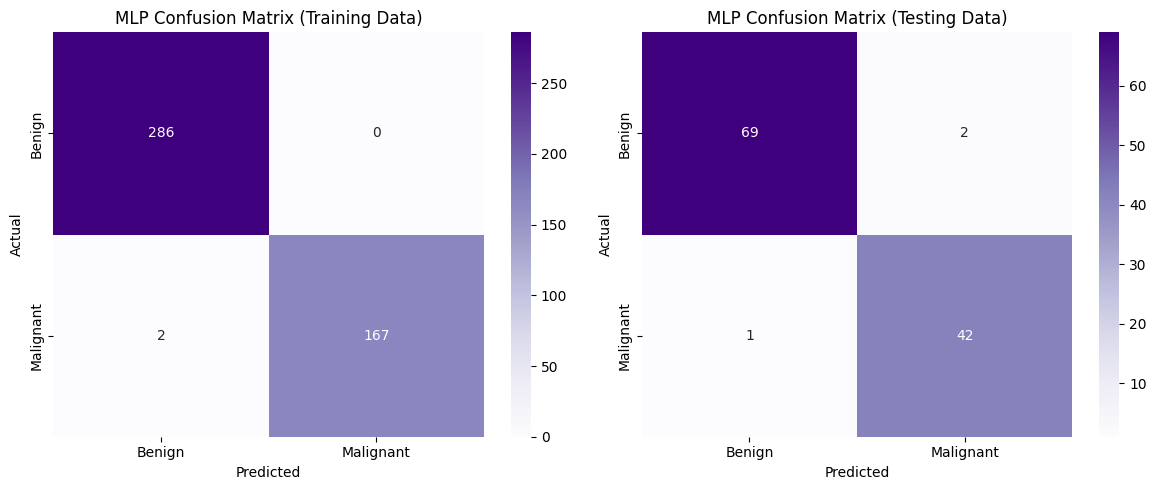

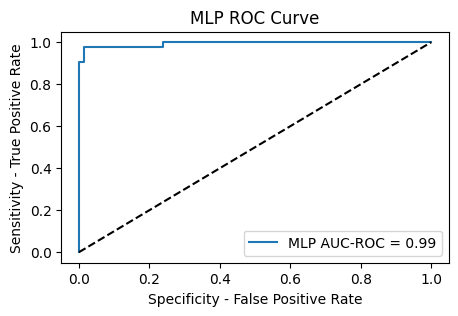

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.model_selection import GridSearchCV

#Define the parameter grid for Grid Search
param_grid = {
   'hidden_layer_sizes': [(50,), (100,), (100, 50)], #different sizes of hidden layers
    'activation': ['relu', 'tanh'], #activation functions decide how and when neurons activate or are fired
    'solver': ['adam', 'lbfgs'], #optimizers adjust weights to minimize the log loss function (cross entropy loss function)
    'learning_rate_init': [0.0001, 0.001, 0.01, 0.04, 1], #controls how much to adjust weights during training
    'max_iter': [1000, 2000, 5000], #number of iterations for training
    'early_stopping': [True], #stops training if it does not improve for a set number of epochs preventing overfitting and unnecessary training epochs
}

#Initialize the MLP classifier
mlp_base = MLPClassifier(random_state=42)

#set up grid search with cross-validation to find the best hyperparameter combination and to evaluate performance across multiple splits.
grid_search = GridSearchCV(estimator=mlp_base, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1) #used 5-fold cross-validation to evaluate performance across multiple splits
grid_search.fit(X_train, y_train.values.ravel())

#Best parameters from Grid Search
best_params = grid_search.best_params_
print("Best parameters from Grid Search:", best_params)

#train the MLP model with the best parameters
mlp_model = grid_search.best_estimator_

#Make predictions on the test set
y_pred_mlp = mlp_model.predict(X_test)

#Evaluate the MLP model
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"MLP Accuracy: {accuracy_mlp}")

# Classification report for MLP
print(classification_report(y_test, y_pred_mlp)) # shows the precision, recall, f1 score and support

#train accuracy for MLP
mlp_train_accuracy = mlp_model.score(X_train, y_train)
print(f"MLP Training Accuracy: {mlp_train_accuracy}")

# Test accuracy for MLP
print(f"MLP Testing Accuracy: {accuracy_mlp}")

#confusion Matrix for MLP
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
# for training set
y_pred_train_mlp = mlp_model.predict(X_train)
cm_train_mlp = confusion_matrix(y_train, y_pred_train_mlp)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#plot training confusion matrix
sns.heatmap(cm_train_mlp, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
axes[0].set_title('MLP Confusion Matrix (Training Data)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

#plot testing confusion matrix
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Purples', ax=axes[1],
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
axes[1].set_title('MLP Confusion Matrix (Testing Data)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

#AUC-ROC Curve helps evaluate the model's ability to distinguish between benign and malignant classes and its performance across all possible thresholds
y_pred_proba_mlp = mlp_model.predict_proba(X_test)[:, 1]
fpr_mlp, tpr_mlp, thresholds_mlp = roc_curve(y_test, y_pred_proba_mlp)
roc_auc_mlp = roc_auc_score(y_test, y_pred_proba_mlp)

plt.figure(figsize=(5, 3))
plt.plot(fpr_mlp, tpr_mlp, label=f'MLP AUC-ROC = {roc_auc_mlp:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Specificity - False Positive Rate')
plt.ylabel('Sensitivity - True Positive Rate')
plt.title('MLP ROC Curve')
plt.legend(loc='lower right')
plt.show()


### Support Vector Machine - SVM

Best Hyperparameters from Grid Search: {'C': 0.01, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'linear'}
Accuracy (with threshold 0.5): 0.9736842105263158
Classification Report (with threshold 0.5):
              precision    recall  f1-score   support

           0       0.99      0.97      0.98        71
           1       0.95      0.98      0.97        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

SVM Training Accuracy: 0.9824175824175824
SVM Testing Accuracy: 0.9736842105263158


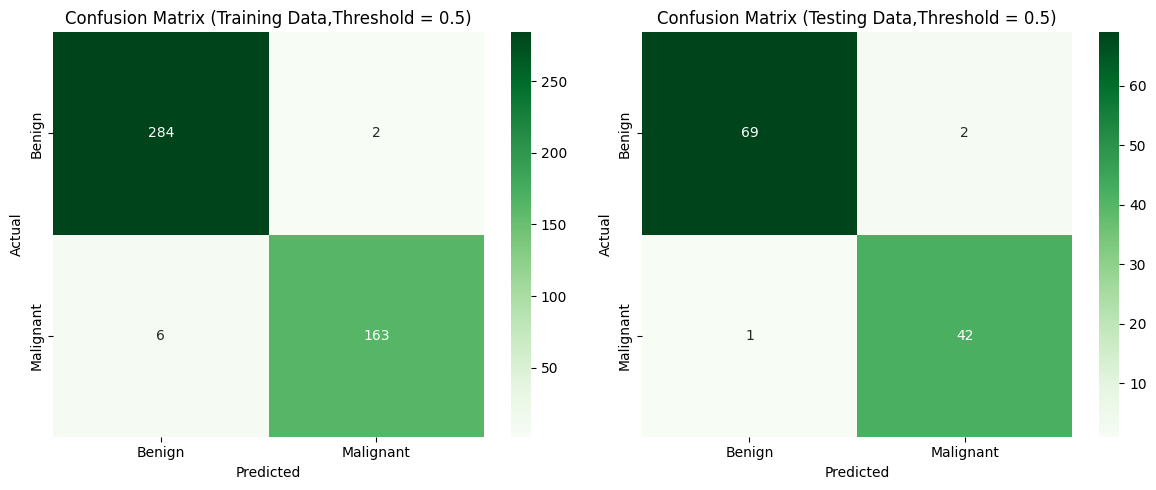

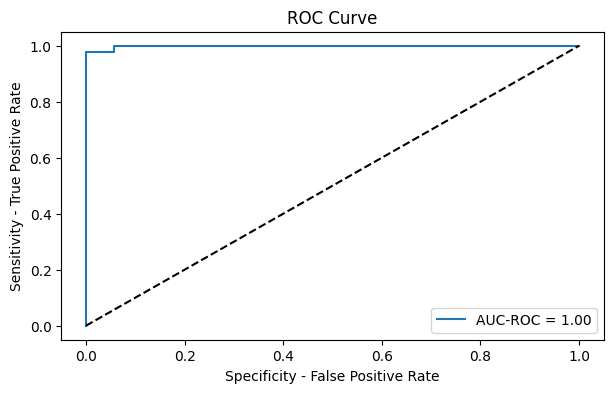

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve

# Define the parameter grid for Grid Search
param_grid = {
    'C': [0.01, 0.05, 0.5, 0.1, 1,10, 15,20], # regularization parameter to control margin large, low c value = less strict, more generalization, some missclassifcation, large c value = more strict, less generalization
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'], #rbf, poly for non linearly
    'gamma': ['scale', 'auto', 0.0001, 0.001, 0.01, 0.1],
    'class_weight': [None, 'balanced', {0: 1, 1: 5}] #Adjusts the importance of classes to handle class imbalance:'balanced' (auto adjust weights based on class frequencies
}                                                    # or custom weights ({0: 1, 1: 5}) to give higher importance to the minority class eg malignant cases

# Perform Grid Search with Cross Validation
grid_search = GridSearchCV(estimator=SVC(probability=True), param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train.values.ravel())

# Get the best hyperparameters
best_params = grid_search.best_params_
print("Best Hyperparameters from Grid Search:", best_params)

# Initialize and train the SVM model with the best parameters
svm_model = SVC(**best_params, probability=True)
svm_model.fit(X_train, y_train.values.ravel())

# Predict probabilities for the positive class (Malignant)
#The model predicts probabilities for both classes, and we extract the probabilities for the malignant class (positive class).
y_pred_proba = svm_model.predict_proba(X_test)[:, 1]

#Decision Threshold
#Sets a threshold value (0.5 by default) to classify the predictions.
#If the predicted probability for the malignant class is greater than or equal to the threshold, classify it as malignant (1) Otherwise, classify it as benign (0).
threshold = 0.5
y_pred_threshold = (y_pred_proba >= threshold).astype(int)

# Evaluate the model with the new threshold
accuracy = accuracy_score(y_test, y_pred_threshold)
print(f"Accuracy (with threshold {threshold}): {accuracy}")

# Classification report
print(f"Classification Report (with threshold {threshold}):")
print(classification_report(y_test, y_pred_threshold))
# Train accuracy for SVM
svm_train_accuracy = svm_model.score(X_train, y_train)
print(f"SVM Training Accuracy: {svm_train_accuracy}")
# Test accuracy for SVM
print(f"SVM Testing Accuracy: {accuracy}")

# Predict on training data
y_train_pred = svm_model.predict(X_train)

# Confusion Matrix for Training Data
cm_train = confusion_matrix(y_train, y_train_pred)

# Confusion Matrix for Testing Data
cm = confusion_matrix(y_test, y_pred_threshold)

# Plotting both confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training Data Confusion Matrix
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
axes[0].set_title(f'Confusion Matrix (Training Data,Threshold = {threshold})')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Testing Data Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
axes[1].set_title(f'Confusion Matrix (Testing Data,Threshold = {threshold})' )
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# AUC-ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)
plt.figure(figsize=(7, 4))
plt.plot(fpr, tpr, label=f'AUC-ROC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('Specificity - False Positive Rate')
plt.ylabel('Sensitivity - True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

### SVM Decision Boundary with PCA-Transformed Scatter Plot for Training and Testing sets

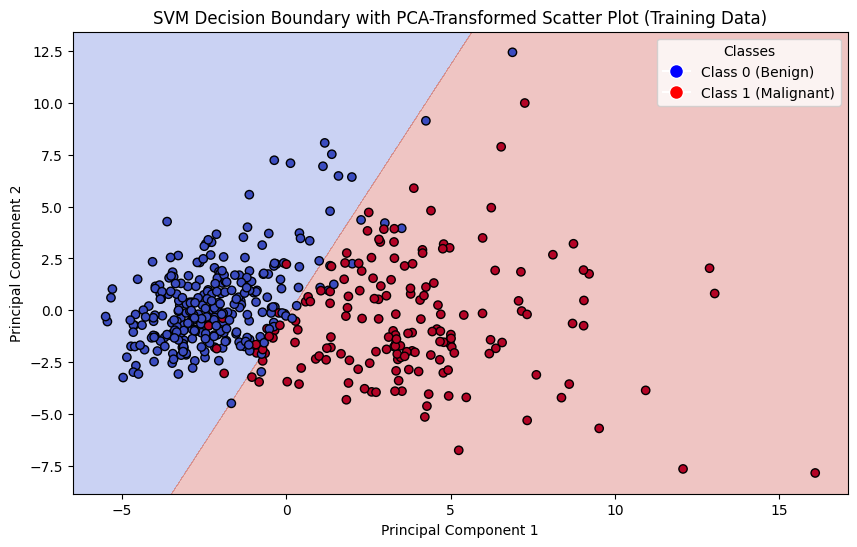

<ipython-input-56-0ab90f80c41f>:45: UserWarning:

You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.



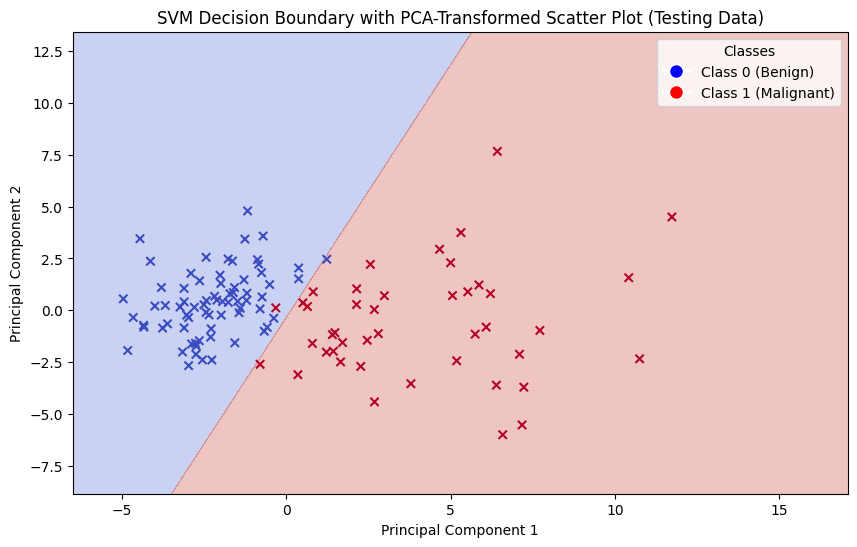

In [ ]:
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D
import numpy as np

# Perform PCA to reduce data to 2 dimensions
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Train the SVM model with the linear kernel on PCA-transformed data
svm_pca_model = SVC(C=0.01, kernel='linear', class_weight='balanced', gamma='scale', probability=True)
svm_pca_model.fit(X_train_pca, y_train.values.ravel())

# Create a mesh grid for plotting decision regions
x_min, x_max = min(X_train_pca[:, 0].min(), X_test_pca[:, 0].min()) - 1, max(X_train_pca[:, 0].max(), X_test_pca[:, 0].max()) + 1
y_min, y_max = min(X_train_pca[:, 1].min(), X_test_pca[:, 1].min()) - 1, max(X_train_pca[:, 1].max(), X_test_pca[:, 1].max()) + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Predict for each point in the mesh grid
Z = svm_pca_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Training Data Scatter Plot
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)  # Filled regions for decision boundary
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train.values.ravel(), cmap=plt.cm.coolwarm, edgecolors='k')

# Add legend for classes
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Class 0 (Benign)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Class 1 (Malignant)')
]
plt.legend(handles=legend_elements, loc='upper right', title="Classes")

# Add labels and title
plt.title('SVM Decision Boundary with PCA-Transformed Scatter Plot (Training Data)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

# Testing Data Scatter Plot
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)  # Filled regions for decision boundary
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test.values.ravel(), cmap=plt.cm.coolwarm, edgecolors='k', marker='x')

# Add legend for classes
plt.legend(handles=legend_elements, loc='upper right', title="Classes")

# Add labels and title
plt.title('SVM Decision Boundary with PCA-Transformed Scatter Plot (Testing Data)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


### XGB Classifier

XGBoost Accuracy: 0.9736842105263158
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

XGBoost Training Accuracy: 0.9978021978021978
XGBoost Testing Accuracy: 0.9736842105263158


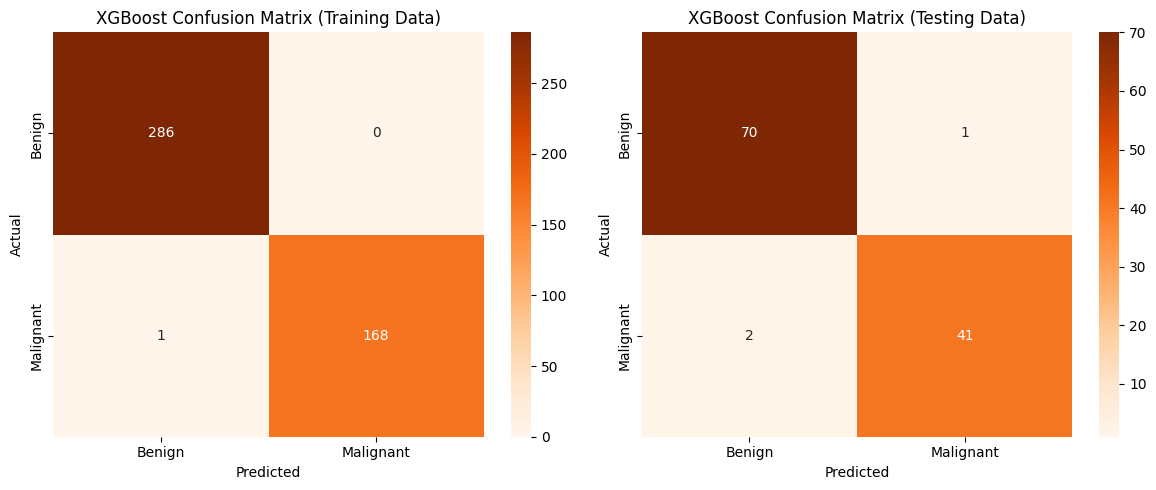

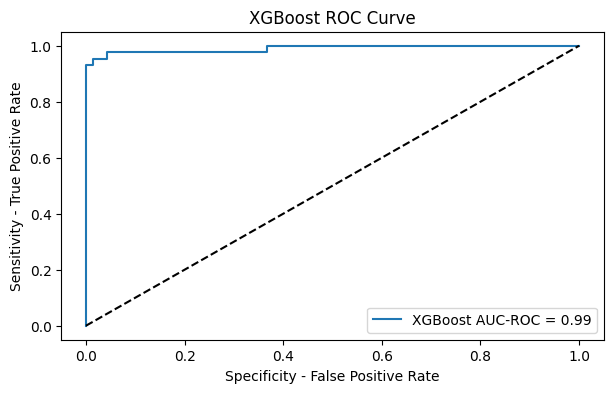

In [ ]:
from xgboost import XGBClassifier

# Initialize and train the XGBoost model
xgb_model = XGBClassifier(
    n_estimators=400,          #the number of boosting rounds or the number of trees to build in the model (training time)
    learning_rate=0.04,       #controls how much the model adjusts or learns with each boosting step balancing speed and accuracy
    max_depth=5,
    min_child_weight=3,        #To Avoid overfitting
    gamma=0.2,
    subsample=0.8,           #introduce randomness by sampling a fraction of data and features
    colsample_bytree=0.8,
    scale_pos_weight=2,      #adjust for class imbalance
    reg_lambda=5,              #L2 Regularisation to improve generalization
    random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the XGBoost model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {accuracy_xgb}")

# Classification report for XGBoost
print(classification_report(y_test, y_pred_xgb))

# Train accuracy for XGBoost
xgb_train_accuracy = xgb_model.score(X_train, y_train)
print(f"XGBoost Training Accuracy: {xgb_train_accuracy}")

# Test accuracy for XGBoost (already calculated and printed as 'accuracy_xgb')
print(f"XGBoost Testing Accuracy: {accuracy_xgb}")

# Confusion Matrix for XGBoost
#for training set
y_pred_train_xgb = xgb_model.predict(X_train)
cm_train_xgb = confusion_matrix(y_train, y_pred_train_xgb)

#for testing set
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot training confusion matrix
sns.heatmap(cm_train_xgb, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
axes[0].set_title('XGBoost Confusion Matrix (Training Data)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Plot testing confusion matrix
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
axes[1].set_title('XGBoost Confusion Matrix (Testing Data)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# AUC-ROC Curve for XGBoost
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_pred_proba_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

plt.figure(figsize=(7, 4))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost AUC-ROC = {roc_auc_xgb:.2f}')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('Specificity - False Positive Rate')
plt.ylabel('Sensitivity - True Positive Rate')
plt.title('XGBoost ROC Curve')
plt.legend(loc='lower right')
plt.show()

### K- Nearest Neighbors

K-NN Accuracy: 0.956140350877193
              precision    recall  f1-score   support

           0       0.96      0.97      0.97        71
           1       0.95      0.93      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

KNN Training Accuracy: 0.9714285714285714
KNN Testing Accuracy: 0.956140350877193


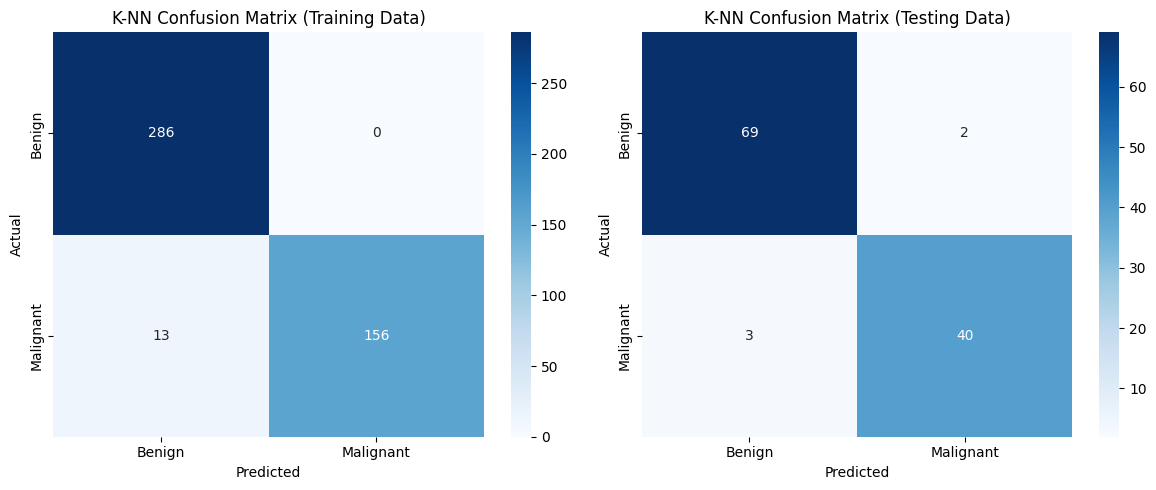

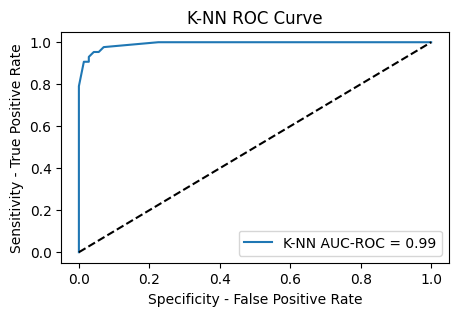

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize and train the K-NN model
knn_model = KNeighborsClassifier(n_neighbors=10)
knn_model.fit(X_train, y_train.values.ravel()) #ravel used to change from 2d to 1d array to ensure compatibility with the KNN model's fit method.

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test)

# Evaluate the K-NN model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"K-NN Accuracy: {accuracy_knn}")

# Classification report for K-NN
print(classification_report(y_test, y_pred_knn))

# Train accuracy for KNN
knn_train_accuracy = knn_model.score(X_train, y_train)
print(f"KNN Training Accuracy: {knn_train_accuracy}")

# Test accuracy for KNN
print(f"KNN Testing Accuracy: {accuracy_knn}")


# Confusion Matrix for K-NN (Training Data)
y_pred_train_knn = knn_model.predict(X_train)
cm_train_knn = confusion_matrix(y_train, y_pred_train_knn)

# Confusion Matrix for K-NN (Testing Data)  # This line is added
cm_knn = confusion_matrix(y_test, y_pred_knn)  # This line is added

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot training confusion matrix
sns.heatmap(cm_train_knn, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
axes[0].set_title('K-NN Confusion Matrix (Training Data)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Plot testing confusion matrix
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
axes[1].set_title('K-NN Confusion Matrix (Testing Data)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# AUC-ROC Curve for K-NN
y_pred_proba_knn = knn_model.predict_proba(X_test)[:, 1]
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, y_pred_proba_knn)
roc_auc_knn = roc_auc_score(y_test, y_pred_proba_knn)

plt.figure(figsize=(5, 3))
plt.plot(fpr_knn, tpr_knn, label=f'K-NN AUC-ROC = {roc_auc_knn:.2f}')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('Specificity - False Positive Rate')
plt.ylabel('Sensitivity - True Positive Rate')
plt.title('K-NN ROC Curve')
plt.legend(loc='lower right')
plt.show()